# 1. Phase explorations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

## Vanilla Kuramoto - Edward-Wilkinson

In [2]:
typenoise = "Columnar"
L = 125
K = 40

deltaname = "0" # EW

path = f"Simulations/Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

2993

In [4]:
simulation = df.iloc[1]
t = simulation["t"]
phases = simulation["phases"]

In [5]:
t, phases.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125))

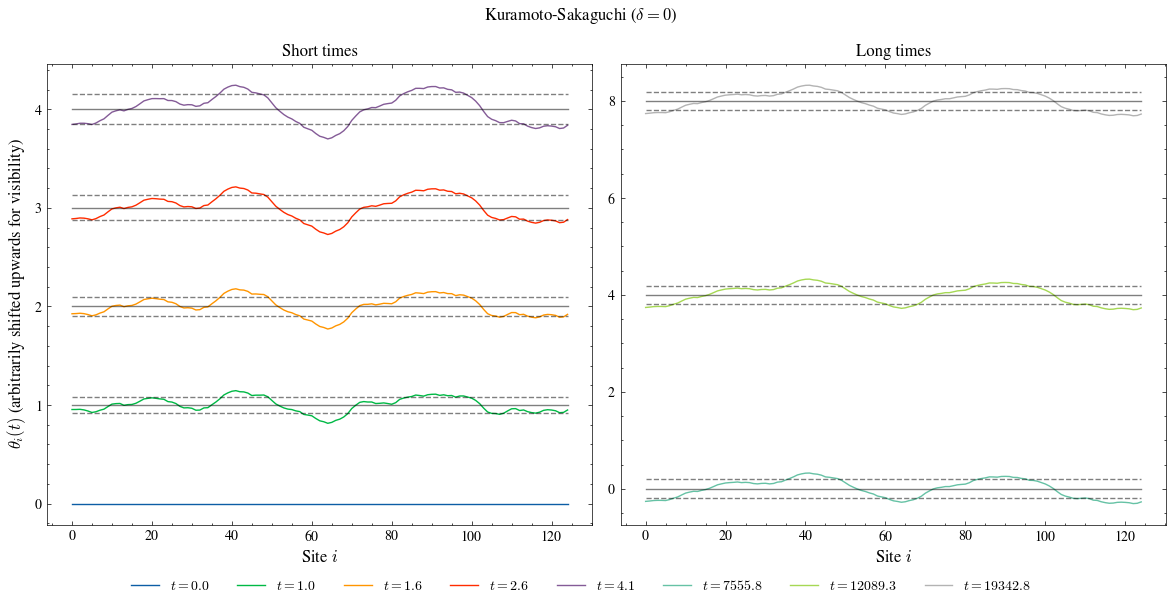

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = 0$)")
fig.supylabel(r"$\theta_i(t)$ (arbitrarily shifted upwards for visibility)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3,4], [0,1,2,3,4]):
    ax[0].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,4,8]), colors):
    ax[1].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
# plt.savefig("Figures/KuramotoPhases.png", dpi=300)

## Kuramoto-Sakaguchi - KPZ

In [8]:
typenoise = "Columnar"
L = 125
K = 40

deltaname = "atan5" # EW

path = f"Simulations/Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

2999

In [9]:
simulation = df.iloc[1]
t = simulation["t"]
phases = simulation["phases"]

In [10]:
t, phases.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125))

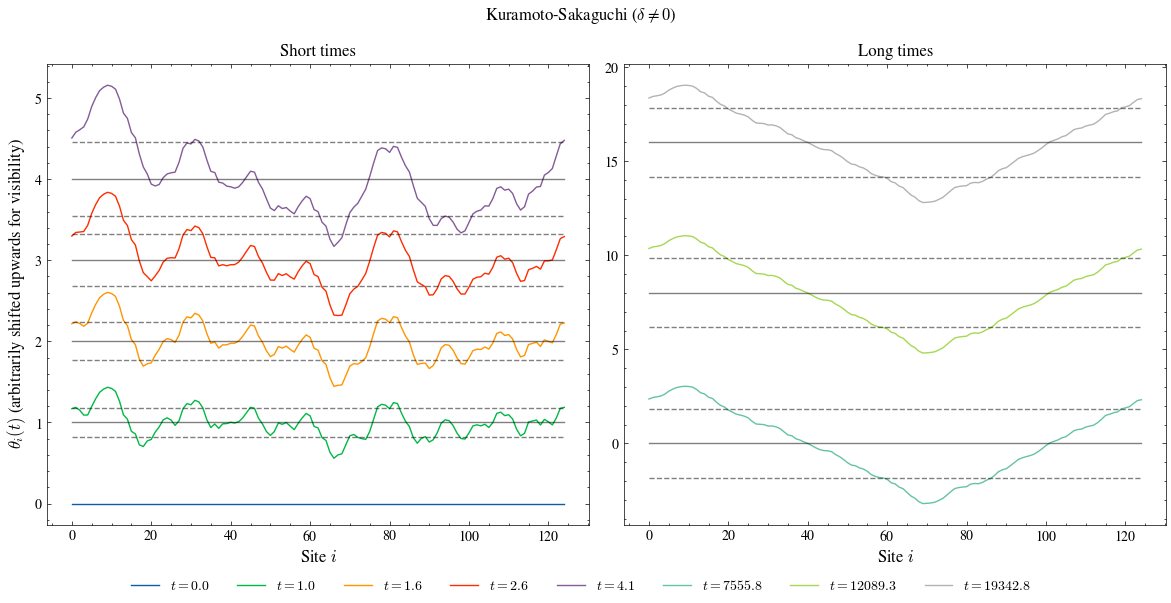

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta \neq 0$)")
fig.supylabel(r"$\theta_i(t)$ (arbitrarily shifted upwards for visibility)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3,4], [0,1,2,3,4]):
    ax[0].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,8,16]), colors):
    ax[1].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
# plt.savefig("Figures/KuramotoSakaguchiPhases.png", dpi=300)